# 10. Noise and Flow Fields

Pure randomness looks like television static; nature's randomness looks like marble, smoke, and wind. Today we meet coherent noise, the tool that fills that gap, and use it to build flow fields: the technique behind some of the most celebrated generative art of the last decade.

## Today's destination

Five thousand particles released into an invisible field of forces, each drawing its path as a single fine line in a dark Rothko palette. Nobody drew any of these lines; we will design the wind, not the strokes. This flow field is the course's poster child, and by the end of today it is yours to steer.

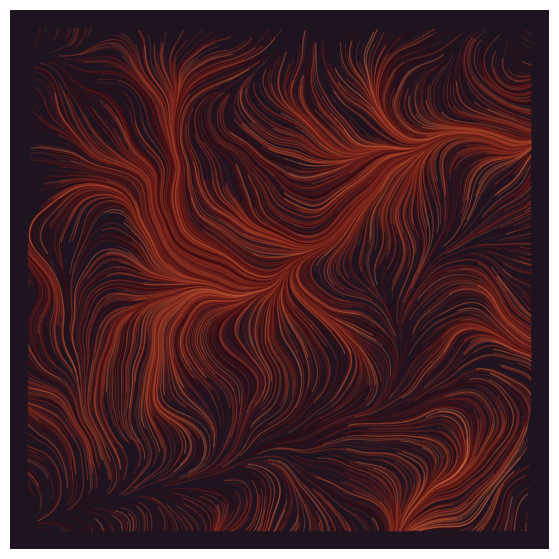

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch10_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(10, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: an Oscar for a texture, and the field that sold out in seconds

In 1982 the computer-animated sequences of *Tron* were state of the art, and **Ken Perlin**, then working at MAGI, one of the studios that produced them, was bothered by exactly that: everything looked machined, clean, dead. His answer, published in 1985, was a procedure for generating *controlled* randomness: smooth, natural-looking variation that could roughen a surface, curl smoke, or age a texture. **Perlin noise** became so fundamental to computer graphics that in 1997 the Academy of Motion Picture Arts and Sciences gave Perlin a Technical Achievement Award for it, an Oscar for a mathematical function. We use its patent-free cousin OpenSimplex (Perlin's own improved *simplex noise* was patented for years, so the open-source world wrote around it), but the idea is the same.

The idea matters to aesthetics far beyond graphics. *Random* and *noisy* name two different textures of chance. The `rng.random()` randomness of chapter 2 is independent from point to point, which is why it reads as static: knowing one pixel tells you nothing about its neighbor. In coherent noise, nearby points agree and distant points drift apart, which is how wood grain, dunes, clouds and water behave. When an artwork feels "organic", spatial correlation is very often the reason, and today that word becomes a dial in your hands.

Flow fields, today's build, are coherent noise's best-known artistic payoff: use noise to assign every point of the canvas a *direction*, then let particles drift along the directions and ink their trails. In June 2021 **Tyler Hobbs** released *Fidenza*, a flow-field algorithm on the platform Art Blocks that generated 999 works, each minted unseen by its collector; editions sold out instantly and resold for sums that made newspapers during the NFT boom (and fell with it). Whatever one thinks of that market, the artistic form it crystallized, **long-form generative art**, is a genuine shift: the artist publishes the *algorithm*, buyers draw random outputs from it, and no cherry-picking is possible. Quality must hold across the whole output distribution, not in one lucky render. Remember Noll's question from chapter 5 (who composed the picked-out best of 500 sheets?); long-form art answers it by forbidding the picking.

## Random is not noisy

Two grayscale squares. Left: chapter 2's randomness, every pixel drawn independently. Right: coherent noise from the `opensimplex` library, sampled on the same grid. Same amount of "chance", entirely different material.

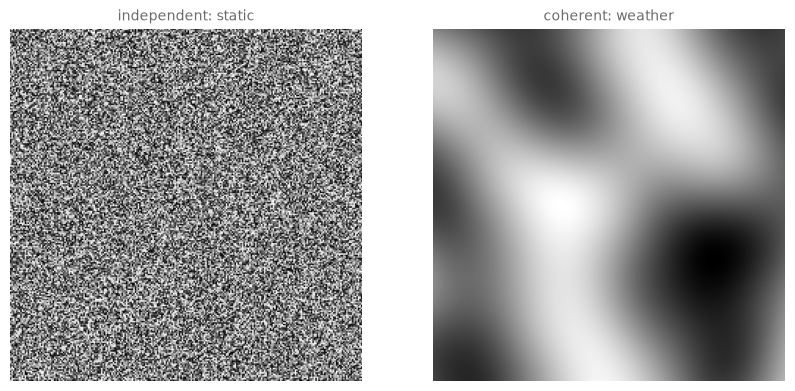

In [2]:
# independent randomness vs coherent noise, side by side
import numpy as np
import matplotlib.pyplot as plt
import opensimplex

rng = np.random.default_rng(1)
static = rng.random((240, 240))

opensimplex.seed(1)
coordinates = np.linspace(0, 3, 240)             # 3 "noise units" across
smooth = opensimplex.noise2array(coordinates, coordinates)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, image, title in [(axes[0], static, "independent: static"),
                         (axes[1], smooth, "coherent: weather")]:
    ax.imshow(image, cmap="gray")
    ax.set_title(title, fontsize=10, color="#6B6B6B")
    ax.axis("off")
plt.show()

## Coherent noise by hand

Before trusting the library, build the principle yourself in 1D; that is this course's habit. Coherent noise is nothing deeper than **smooth interpolation between random anchor values**: draw a random value at every whole number, then connect them not with straight lines but with an S-curve that flattens out at each anchor,

$$t_{\text{smooth}} = 3t^2 - 2t^3,$$

the *smoothstep* function, which rises from 0 to 1 like a lazy diagonal. The result wanders unpredictably yet has no kinks: a one-dimensional landscape.

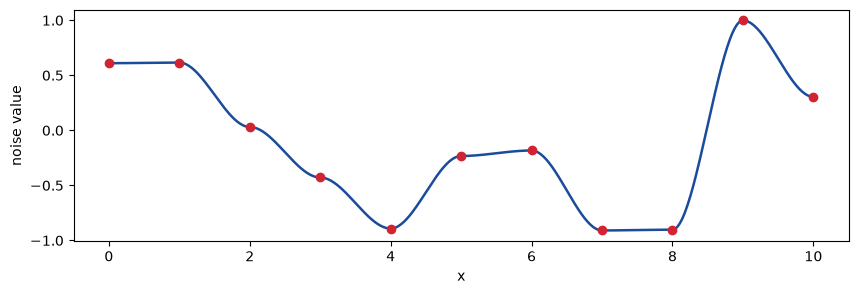

In [3]:
# value noise in 1D: random anchors at whole numbers, smoothstep in between
rng = np.random.default_rng(5)
anchors = rng.uniform(-1, 1, 11)                 # one value at x = 0, 1, ... 10

xs = np.linspace(0, 10, 500)
left = np.clip(xs.astype(int), 0, 9)             # which anchor is to my left?
t = xs - left                                    # how far toward the next one?
t_smooth = 3 * t ** 2 - 2 * t ** 3               # the S-curve
values = anchors[left] * (1 - t_smooth) + anchors[left + 1] * t_smooth

plt.figure(figsize=(10, 3))
plt.plot(xs, values, color="#1B4B9B", linewidth=1.8)
plt.plot(range(11), anchors, "o", color="#D02433", markersize=6)
plt.xlabel("x")
plt.ylabel("noise value")
plt.show()

The red dots are the only random decisions; everything between them is deterministic smoothing. (The library's simplex noise refines this recipe, interpolating random *slopes* instead of values on a cleverer lattice, but the anchors-plus-smoothing idea is all you need to reason about it.)

One layer of this is too smooth to pass for nature: real terrain has hills *and* pebbles. The classic fix is stacking **octaves** (Oktaven, borrowed from music because each layer doubles the frequency): add the noise to a half-amplitude copy at double frequency, then a quarter-amplitude copy at quadruple frequency, and so on. The doubling factor is called *lacunarity*, the amplitude factor *persistence*.

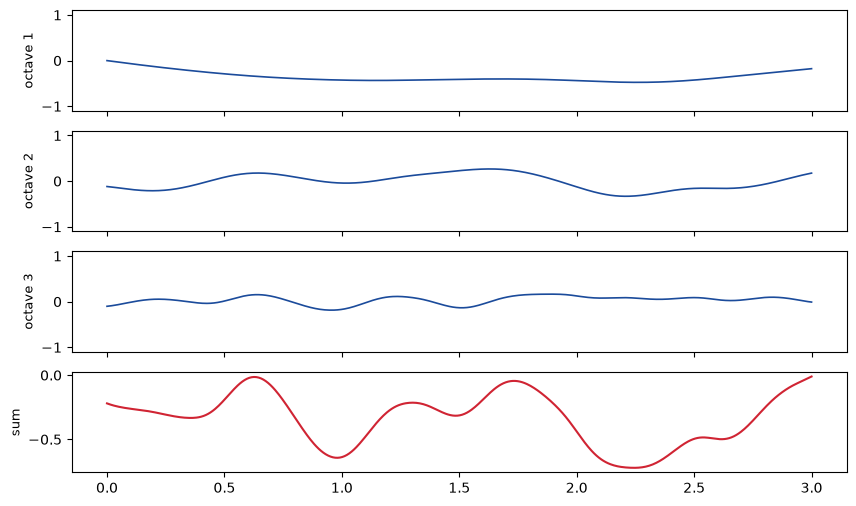

In [4]:
# octave stacking in 1D: detail accumulates without losing the large shape
opensimplex.seed(7)
xs = np.linspace(0, 3, 600)

fig, axes = plt.subplots(4, 1, figsize=(10, 6), sharex=True)
total = np.zeros(len(xs))
for octave in range(3):
    frequency = 2 ** octave                      # 1, 2, 4  (lacunarity 2)
    amplitude = 0.5 ** octave                    # 1, 1/2, 1/4  (persistence 0.5)
    # each octave samples its own y-slice of the noise (any offset works)
    layer = amplitude * opensimplex.noise2array(xs * frequency,
                                                np.array([octave * 9.7]))[0]
    total = total + layer
    axes[octave].plot(xs, layer, color="#1B4B9B", linewidth=1.2)
    axes[octave].set_ylabel(f"octave {octave + 1}", fontsize=9)
    axes[octave].set_ylim(-1.1, 1.1)
axes[3].plot(xs, total, color="#D02433", linewidth=1.5)
axes[3].set_ylabel("sum", fontsize=9)
plt.show()

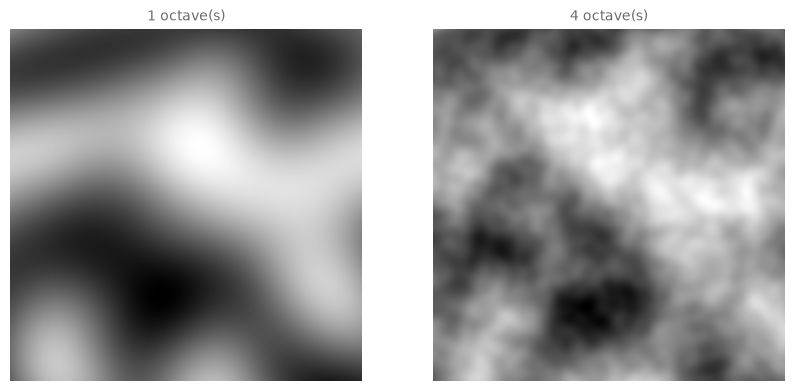

In [5]:
# the same recipe in 2D, wrapped as a function for the rest of the chapter
def octave_noise(xs, ys, octaves=3, persistence=0.5, lacunarity=2.0):
    total = np.zeros((len(ys), len(xs)))
    amplitude = 1.0
    frequency = 1.0
    for octave in range(octaves):
        total += amplitude * opensimplex.noise2array(xs * frequency,
                                                     ys * frequency)
        amplitude *= persistence
        frequency *= lacunarity
    return total / np.max(np.abs(total))         # normalized to -1 ... 1

coordinates = np.linspace(0, 3, 300)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, n_octaves in [(axes[0], 1), (axes[1], 4)]:
    ax.imshow(octave_noise(coordinates, coordinates, n_octaves), cmap="gray")
    ax.set_title(f"{n_octaves} octave(s)", fontsize=10, color="#6B6B6B")
    ax.axis("off")
plt.show()

**Try it.** Set `persistence=0.8` in the right panel's call: the pebbles start shouting over the hills. Persistence is a balance-of-power dial between the scales.

## From noise to flow: every point gets a direction

Here is the move that turns a texture into a *force*. A noise value is a number between $-1$ and $1$; multiply it by $\pi$ and it is an **angle** between $-\pi$ and $\pi$. Do that at every point of the canvas and you have a **vector field** (Vektorfeld): an invisible wind blowing in a smoothly varying direction everywhere. The diagram below draws one arrow per grid cell, chapter 8's `np.meshgrid` supplying the grid, exactly as promised.

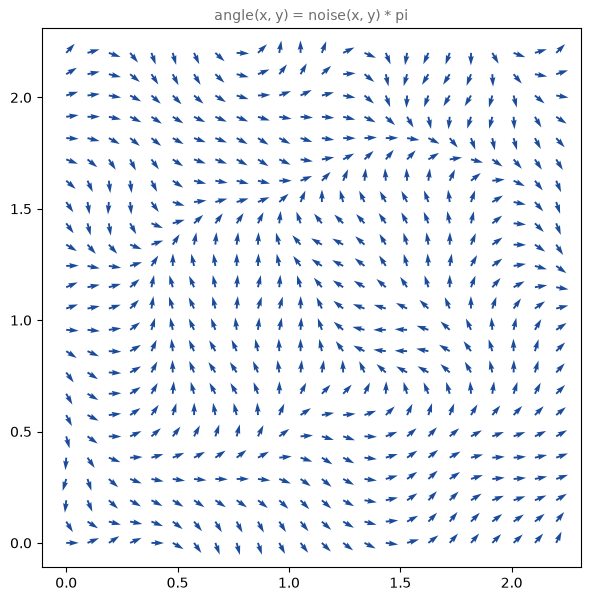

In [6]:
# the invisible wind, made visible: one arrow per cell of a coarse grid
opensimplex.seed(11)
coarse = np.linspace(0, 2.2, 24)
angles = octave_noise(coarse, coarse, octaves=2) * np.pi

xx, yy = np.meshgrid(coarse, coarse)
plt.figure(figsize=(7, 7))
plt.quiver(xx, yy, np.cos(angles), np.sin(angles),
           color="#1B4B9B", width=0.0035)
plt.gca().set_aspect("equal")
plt.title("angle(x, y) = noise(x, y) * pi", fontsize=10, color="#6B6B6B")
plt.show()

## Tracing particles

Now release particles into the wind. Each particle repeats one tiny rule: *look up the angle where I stand, take a small step in that direction*. Collecting the positions gives a trail per particle, and the trails are the artwork.

One honest performance note: computing fresh noise at every particle position at every step is the textbook version, but it is slow in pure Python. We precompute the angles once on a fine grid and let particles look their angle up, which is thousands of times faster and visually indistinguishable. Particles that wander off the canvas end their trail (`np.nan` positions create exactly the line break we want when drawing). Two numpy idioms carry the code: `np.where(condition, a, b)` picks from `a` where the condition holds and from `b` elsewhere, an if/else for whole arrays; and `np.nan_to_num` turns the dead particles' `nan` into 0 so the grid lookup stays legal (the `np.where` keeps them dead regardless).

In [7]:
# particles stepping through the angle grid; histories become trails
def trace_particles(angles, n_particles, n_steps, step_size, rng):
    resolution = angles.shape[0]
    x = rng.random(n_particles)
    y = rng.random(n_particles)
    xs_history = np.full((n_steps + 1, n_particles), np.nan)
    ys_history = np.full((n_steps + 1, n_particles), np.nan)
    xs_history[0] = x
    ys_history[0] = y
    for step in range(1, n_steps + 1):
        inside = (x >= 0) & (x < 1) & (y >= 0) & (y < 1)
        column = np.clip((np.nan_to_num(x) * resolution).astype(int),
                         0, resolution - 1)
        row = np.clip((np.nan_to_num(y) * resolution).astype(int),
                      0, resolution - 1)
        angle = angles[row, column]
        x = np.where(inside, x + step_size * np.cos(angle), np.nan)
        y = np.where(inside, y + step_size * np.sin(angle), np.nan)
        xs_history[step] = x
        ys_history[step] = y
    return xs_history, ys_history

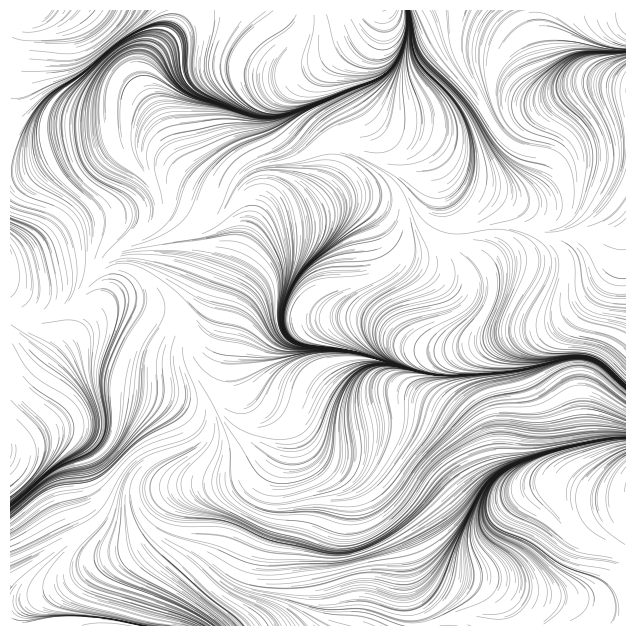

In [8]:
# first flight: two thousand particles, plain ink
from matplotlib.collections import LineCollection

opensimplex.seed(3)
fine = np.linspace(0, 2.5, 400)
angles = octave_noise(fine, fine, octaves=3) * np.pi

rng = np.random.default_rng(3)
xs_history, ys_history = trace_particles(angles, n_particles=2000,
                                         n_steps=200, step_size=0.0025, rng=rng)

# .T flips the histories so each row is one particle; np.stack then
# glues x and y into (x, y) pairs: one polyline per particle
trails = np.stack([xs_history.T, ys_history.T], axis=-1)
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(LineCollection(trails, colors="#1A1A1A",
                                 linewidths=0.5, alpha=0.35))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

Already recognizably a flow field: dense currents, calm eddies, empty shorelines where the wind blows particles away. Three dials will now take this from sketch to artwork:

- **noise scale**: how many noise units span the canvas; low is laminar (calm, parallel currents), high is turbulent;
- **swirl**: how much of the full circle the angles may use. A full $2\pi$ lets currents loop back on themselves; a narrow swirl around a base direction (*drift*) combs everything one way, like brushed hair;
- **palette and weights**: line colors drawn by weighted choice, chapter 2's oldest trick, so one color can dominate and another appear as a rare accent.

**Try it.** In the cell above, change `octaves=3` to `1` and the field combs itself smooth; the eddies were the upper octaves' work.

In [9]:
# the finished generator, part 1: the wind
def flow_angles(seed, scale=2.5, octaves=3, swirl=2 * np.pi, drift=0.0,
                resolution=400):
    opensimplex.seed(seed)
    coordinates = np.linspace(0, scale, resolution)
    noise = octave_noise(coordinates, coordinates, octaves)
    return drift + noise * swirl / 2

# part 2: drawing the trails onto an axis
def draw_trails(ax, xs_history, ys_history, colors, linewidths, alpha,
                background):
    trails = np.stack([xs_history.T, ys_history.T], axis=-1)
    ax.add_collection(LineCollection(trails, colors=colors,
                                     linewidths=linewidths, alpha=alpha))
    ax.set_facecolor(background)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect("equal")
    ax.axis("off")

In [10]:
# part 3: the whole piece -- wind, particles, weighted colors, varied widths
import sys
sys.path.append("..")
from agap.helpers import PALETTES, PAPER, save_artwork

def flow_field(seed=8, n_particles=3000, n_steps=250, step_size=0.0025,
               scale=2.5, octaves=3, swirl=2 * np.pi, drift=0.0,
               palette=None, weights=None, background="#1E1420",
               width_range=(0.3, 1.4), alpha=0.5, quality=1.0):
    if palette is None:
        palette = PALETTES["rothko_dark"][:4]
    n_particles = int(n_particles * quality)     # rendering budget dial
    angles = flow_angles(seed, scale, octaves, swirl, drift)
    rng = np.random.default_rng(seed)
    xs_history, ys_history = trace_particles(angles, n_particles,
                                             n_steps, step_size, rng)
    color_index = rng.choice(len(palette), n_particles, p=weights)
    colors = []
    for index in color_index:
        colors.append(palette[index])
    linewidths = rng.uniform(width_range[0], width_range[1], n_particles)
    fig, ax = plt.subplots(figsize=(8, 8), facecolor=background)
    draw_trails(ax, xs_history, ys_history, colors, linewidths, alpha,
                background)
    plt.show()
    return fig

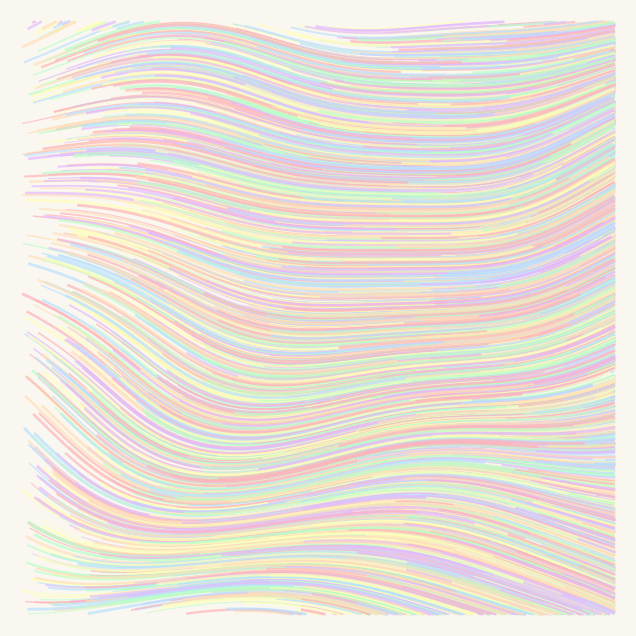

In [11]:
# temperament 1: laminar drift -- narrow swirl, pastel on paper
art_1 = flow_field(seed=21, scale=1.4, octaves=2, swirl=1.6, drift=0.0,
                   palette=PALETTES["pastel"], background=PAPER,
                   width_range=(0.6, 2.2), alpha=0.7)

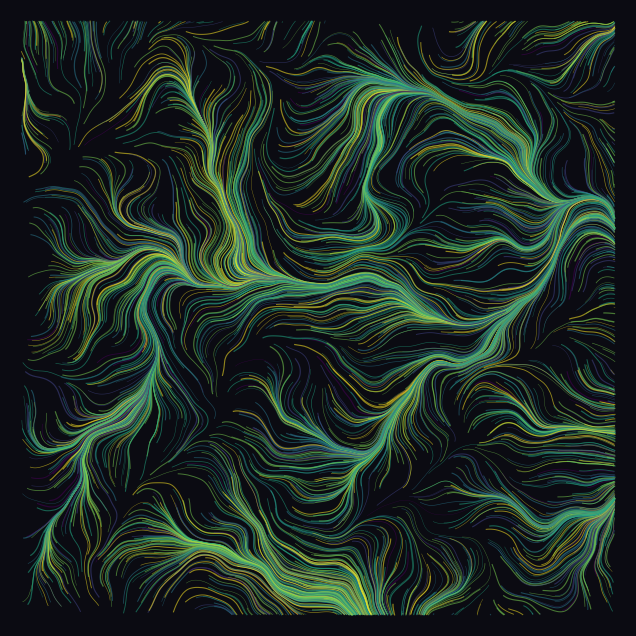

In [12]:
# temperament 2: turbulence -- high scale, full swirl, viridis on near-black
art_2 = flow_field(seed=5, scale=4.5, octaves=4, swirl=2 * np.pi,
                   palette=PALETTES["viridis"], background="#0B0B12",
                   weights=[0.05, 0.1, 0.2, 0.25, 0.25, 0.15],
                   width_range=(0.25, 0.9), alpha=0.55)

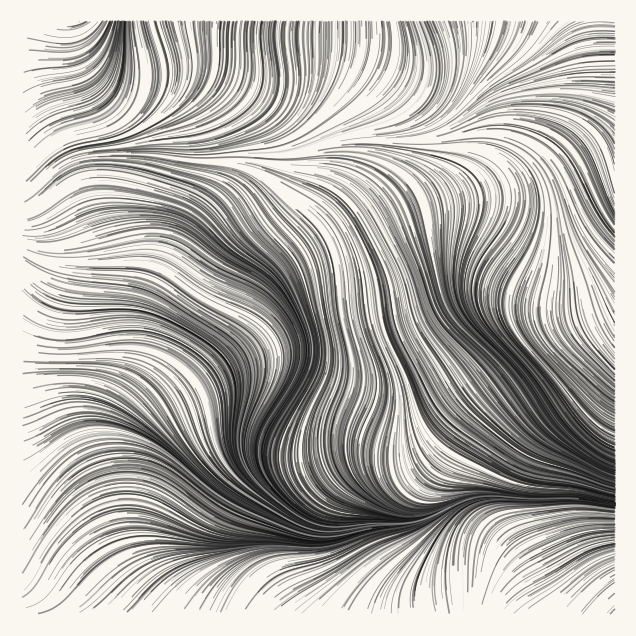

In [13]:
# temperament 3: ink study -- monochrome, one dominant tone, rare pale accent
art_3 = flow_field(seed=13, scale=2.0, octaves=3, swirl=4.5,
                   palette=PALETTES["monochrome"], background=PAPER,
                   weights=[0.5, 0.25, 0.12, 0.08, 0.03, 0.02],
                   width_range=(0.3, 1.2), alpha=0.45)

**Look and compare.** The three temperaments differ in scale, swirl and palette at once. Which one feels *slow*? Find the single parameter most responsible, then test your hypothesis by changing only it. And a Fidenza-flavored question: if you had to publish ONE of these three configurations as a long-form series of 999 seeds, sight unseen, which would you trust to stay good across all 999, and why? (Consistent quality and peak quality are different virtues; collectors of generative art discuss exactly this.)

## The showpiece

Five thousand particles, the dark Rothko palette over near-black, deep reds dominant and the pale orange rationed to a scattering of embers. On a laptop this renders in well under a minute; for a poster-sized print at home, raise `quality` to 2 or 3 and `n_steps` to 500, and expect a coffee break.

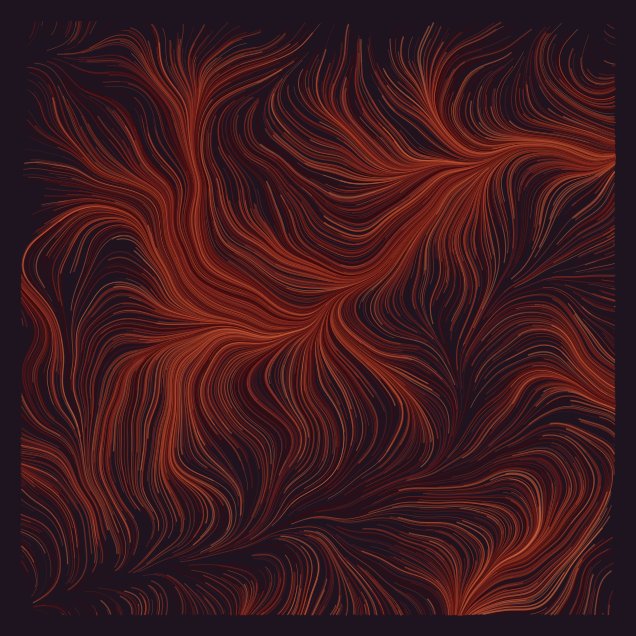

In [14]:
# the showpiece: 5000 particles in ember light
def flow_showpiece(quality=1.0):
    return flow_field(seed=8, n_particles=5000, n_steps=320,
                      scale=2.2, octaves=4, swirl=2 * np.pi,
                      palette=PALETTES["rothko_dark"][:4],
                      weights=[0.38, 0.30, 0.20, 0.12],
                      background="#1E1420", width_range=(0.25, 1.1),
                      alpha=0.5, quality=quality)

showpiece = flow_showpiece()

## Export your artwork

Tune a field until it is yours, then export. Replace `yourname` and run; the print-quality PNG lands in `assets/outputs/`.

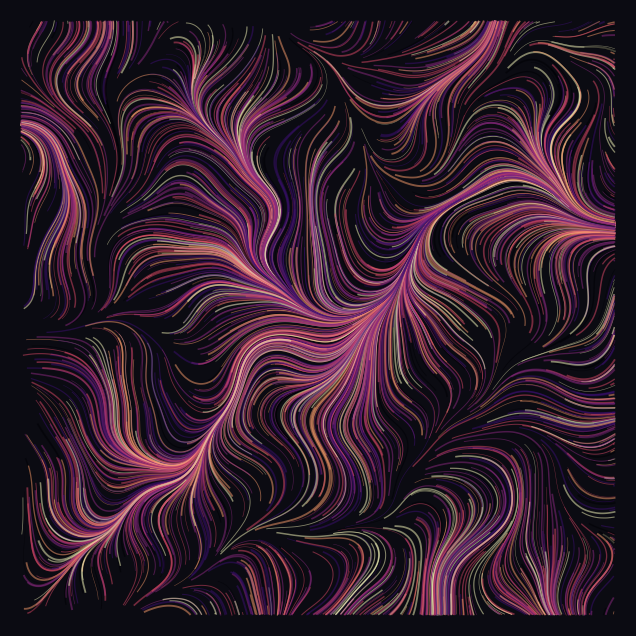

saved: assets/outputs/ch10_yourname.png


In [15]:
# save YOUR artwork: adjust parameters, replace 'yourname', run the cell
my_artwork = flow_field(seed=2026, scale=2.8, octaves=3,
                        palette=PALETTES["magma"], background="#0B0B12",
                        weights=[0.1, 0.2, 0.25, 0.2, 0.15, 0.1])
saved_path = save_artwork(my_artwork, "yourname", chapter=10)

## Exercises

**(a) Parameter exploration: from turbulence to lamination.** Render the same seed at `scale` 0.8, 1.6, 3.2, 6.4 (everything else fixed). Somewhere in that sweep the image changes species, from weather map to combed silk. Which scale would you hang in a bedroom, and which in a techno club? Defend the difference in one sentence about spatial frequency.

**(b) Code modification: die and be reborn.** Our particles that leave the canvas are gone for good, so long runs drain the image. Modify `trace_particles` so that a particle leaving the canvas *respawns* at a fresh random position, leaving a break in its trail. The `np.nan` trick does the breaking for you: record `nan` at the step where the particle dies, then continue the history from the new position; matplotlib renders the gap automatically.

<details><summary>Solution</summary>

```python
def trace_particles_respawn(angles, n_particles, n_steps, step_size, rng):
    resolution = angles.shape[0]
    x = rng.random(n_particles)
    y = rng.random(n_particles)
    xs_history = np.full((n_steps + 1, n_particles), np.nan)
    ys_history = np.full((n_steps + 1, n_particles), np.nan)
    xs_history[0] = x
    ys_history[0] = y
    for step in range(1, n_steps + 1):
        column = np.clip((np.nan_to_num(x) * resolution).astype(int),
                         0, resolution - 1)
        row = np.clip((np.nan_to_num(y) * resolution).astype(int),
                      0, resolution - 1)
        angle = angles[row, column]
        x = x + step_size * np.cos(angle)
        y = y + step_size * np.sin(angle)
        outside = (x < 0) | (x >= 1) | (y < 0) | (y >= 1)
        xs_history[step] = np.where(outside, np.nan, x)   # gap in the trail
        ys_history[step] = np.where(outside, np.nan, y)
        x = np.where(outside, rng.random(n_particles), x)  # reborn elsewhere
        y = np.where(outside, rng.random(n_particles), y)
    return xs_history, ys_history

opensimplex.seed(3)
fine = np.linspace(0, 2.5, 400)
angles = octave_noise(fine, fine, octaves=3) * np.pi
rng = np.random.default_rng(3)
xs_history, ys_history = trace_particles_respawn(angles, 2000, 400,
                                                 0.0025, rng)
fig, ax = plt.subplots(figsize=(8, 8))
draw_trails(ax, xs_history, ys_history, "#1A1A1A", 0.5, 0.3, "white")
plt.show()
```

Compare coverage with the original at the same 400 steps: the respawning version fills the canvas evenly instead of developing bald patches. (The `rng.random(n_particles)` respawn draws fresh positions for every particle and keeps only the dead ones' values via `np.where`; wasteful but simple, and simple wins.)
</details>

**(c) Creative challenge: shape the space.** Two classic moves, pick one. *Mask*: only draw trail points inside a circle around the canvas center (set positions outside the circle to `np.nan` after tracing; the artwork becomes a tondo, a circular painting). *Obstacle*: before tracing, override the angle grid so that near a chosen point all angles point directly away from it; the flow parts around an invisible stone. Combine with a palette of your own for the gallery.

## Further reading

- Tyler Hobbs, the essays "Flow Fields" and "The Rise of Long-Form Generative Art" on [tylerxhobbs.com](https://www.tylerxhobbs.com/): a leading practitioner explaining both the technique and the art form's economics from inside.
- Ken Perlin, "An Image Synthesizer", *SIGGRAPH* 1985: the original noise paper, short and surprisingly readable.
- Daniel Shiffman, [*The Nature of Code*, chapter "Randomness"](https://natureofcode.com/random/): Perlin noise built up gently, in JavaScript but directly translatable to today's Python.
- [Art Blocks](https://www.artblocks.io/): browse the curated collections and judge long-form consistency for yourself, Fidenza included.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook. It runs automatically with *Restart & Run All*.

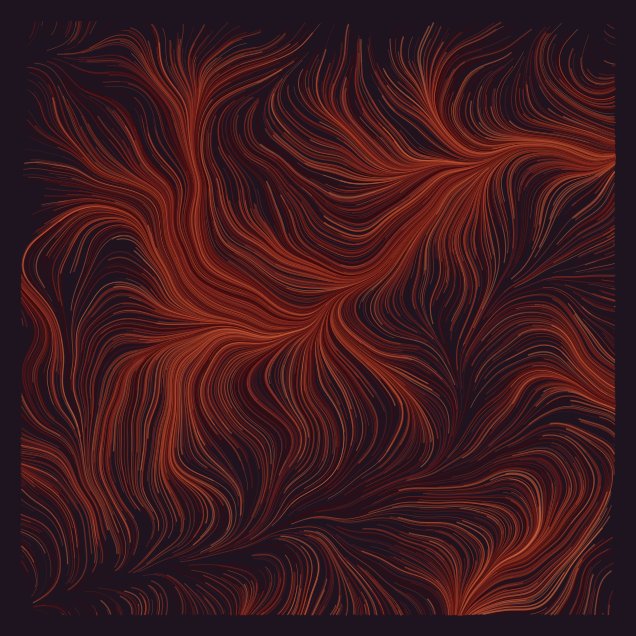

saved: assets/outputs/ch10_showpiece.png


In [16]:
# regenerate this chapter's showpiece: the ember flow field
showpiece = flow_showpiece()
saved_path = save_artwork(showpiece, "showpiece", chapter=10)